
# Database of indoor $CO_2$ measurements

### Santiago Correa Restrepo
### santiagocorrea251469@correo.itm.edu.co

---

<br/>

# 1. IndoorCO2Map Context

IndoorCO2Map is a project developed in Germany by Aurel Wuensch, which seeks to record air quality inside commercial premises by measuring $CO_2$ concentration in ppm. This measurement is carried out with the help of the community. They developed a mobile and [Website](https://github.com/AurelWu/IndoorCO2AppMAUI/tree/master) application so that users can connect a $CO_2$ sensor and upload the results to a database.

The database is available on the creator's [GitHub](https://github.com/AurelWu/IndoorCO2AppMAUI/tree/master), in a .JSON file. Although this database is global, community participation is skewed towards European countries (due to issues of accessibility and influence). A record in the database is equivalent to initiating a $CO_2$ measurement sequence in a short period of time (min), taking data such as information on the premises, location, natural and/or active mechanical ventilation, date + time of measurement start, time interval between measurements, and eventually a list of the X $CO_2$ measurements.

Databases that study CO2 pollution tend to focus on atmospheric pollution, thus evaluating pollution from anthropogenic industrial sources and obtaining a general overview of the danger of CO2 in that locality. Still, they ignore the accumulation of CO2 inside a building, where most humans gather and where the danger of the gas is intensified (due to biological emissions and poor ventilation).

## IndoorCO2Map Original Database

<iframe src="https://indoorco2map.com/?lat=19.34553&lng=4.50000&zoom=1.37" 
        loading="lazy" 
        style="width: 100%; height: 650px; border: 1px solid #ccc;" 
        allowfullscreen>
</iframe>

**Reference:** Indoor $CO_2$ Map Project. (n.d.). Retrieved on September 29 - 2025,  https://indoorco2map.com/

 The importance of an indoor $CO_2$ database allows users, workers, and owners to take action on health, policy, and marketing issues. Since a database such as IndoorCO2map analyzes comparisons between regions, types of premises, and ventilation conditions.

# 2. Data management

## Load database

In [101]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
import seaborn as sns
from scipy.stats import kstest, zscore, kruskal, chi2_contingency



We used the **requests** and **pandas** libraries to retrieve a file (.JSON) from the official GitHub URL of the creator of IndoorCO2Maps and save it in a pandas DataFrame. A preview of the columns and data types was also applied.

In [2]:

# Load data from a JSON file and convert it into a pandas DataFrame

class DataLoad:
    def __init__(self, url):
        self.url = url

    def __call__(self):
        response = requests.get(self.url)
        response.raise_for_status() 
        data = response.json()
        df = pd.DataFrame(data)
        return df


url = "https://raw.githubusercontent.com/Yeikeer/IndoorCO2Map-Analysis/main/Lab%201/indoorco2mapData.json"


indoorco2map = DataLoad(url)()

print(f'\nDataFrame columns: {indoorco2map.columns.tolist()}') # Print the first rows of the DataFrame
print(indoorco2map.info())
display(indoorco2map.head(6))



DataFrame columns: ['nwrtype', 'nwrID', 'name', 'latitude', 'longitude', 'countryID', 'countryName', 'nuts3ID', 'nuts3Name', 'osmKey', 'osmTag', 'brand', 'startOfMeasurement', 'windowsOpen', 'ventilationSystem', 'customNotes', 'co2readings', 'offset', 'interval', 'co2readingsAvg']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12681 entries, 0 to 12680
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nwrtype             12681 non-null  object 
 1   nwrID               12681 non-null  int64  
 2   name                12681 non-null  object 
 3   latitude            12681 non-null  float64
 4   longitude           12681 non-null  float64
 5   countryID           12681 non-null  object 
 6   countryName         12681 non-null  object 
 7   nuts3ID             12681 non-null  object 
 8   nuts3Name           12681 non-null  object 
 9   osmKey              12681 non-null  object 
 10  osmTag         

,nwrtype,nwrID,name,latitude,longitude,countryID,countryName,nuts3ID,nuts3Name,osmKey,osmTag,brand,startOfMeasurement,windowsOpen,ventilationSystem,customNotes,co2readings,offset,interval,co2readingsAvg
0,n,4436021034,Konsum,51.340164,12.366027,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,supermarket,Konsum Leipzig,2024-05-15T17:10:19.811,False,True,,"[544, 573, 547, 533, 595, 601]",0,1,566
1,n,386028187,Konsum Leipzig,51.300839,12.397328,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,supermarket,Konsum Leipzig,2024-05-16T10:27:41.828,False,True,,"[680, 672, 640, 661, 651]",0,1,661
2,n,1706619258,Konsum,51.278852,12.369599,DEU,Germany,DED52,Leipzig,shop,supermarket,Konsum Leipzig,2024-05-17T10:44:03.095,True,True,,"[897, 903, 985, 998, 871, 959]",0,1,936
3,w,248962888,REWE,51.310976,12.373789,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,supermarket,REWE,2024-04-15T19:24:48.298,False,True,,"[1202, 1568, 1689, 1690, 1703, 1607]",0,1,1576
4,n,4271724130,Konsum,51.311495,12.379476,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,supermarket,Konsum Leipzig,2024-04-11T18:08:34.631,False,True,,"[549, 711, 746, 738, 776, 790, 761]",0,1,724
5,n,7089534833,Subway,51.315186,12.373109,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",amenity,fast_food,Subway,2024-04-14T16:42:15.518,True,False,,"[497, 484, 487, 478, 483, 499, 470, 472, 509, ...",0,1,486


## Filter data

The database has many columns with empty values, but these values are usually characters with space values, written words that refer to nothing, but for Python they count as characters: *(“”), (“ ”), (‘Nan’), (N/A“), (”None")*, among others. Numeric characteristics are considered valid values of *“0”*, therefore, only those that are null create a class to convert these values to the **mean** or **median** of the data, and categorical values or characters are imputed by the **mode** of the values.

In [3]:
class DataCleaner:
    def __init__(self, df):
        self.df = df

    def __call__(self, method="mean"):

        # clean empty strings and common NaN representations of pandas and numpy null values
        self.df = self.df.replace(
            [r'^\s*$', 'NaN', 'nan', 'NAN', 'N/A', 'None', None],
            np.nan,
            regex=True
        )

        # Identify columns with list or dict types to exclude them from imputation
        list_cols = [
            col for col in self.df.columns 
            if self.df[col].apply(lambda x: isinstance(x, (list, dict))).any()
        ]

        # numeric columns imputation
        num_cols = self.df.select_dtypes(include='number').columns.difference(list_cols)
        if method == "mean":
            self.df[num_cols] = self.df[num_cols].fillna(self.df[num_cols].mean())
        elif method == "median":
            self.df[num_cols] = self.df[num_cols].fillna(self.df[num_cols].median())
        else:
            raise ValueError('Use mean or median')

        # string/categorical columns imputation
        cat_cols = self.df.select_dtypes(exclude=['number']).columns.difference(list_cols)
        for col in cat_cols:
            mode_series = self.df[col].mode()
            if not mode_series.empty:
                self.df[col].fillna(mode_series.iloc[0], inplace=True)

        return self.df

In [4]:
# aplly data cleaning class
cleaner = DataCleaner(indoorco2map)
indoorco2map = cleaner("mean")

# Verify no missing values remain
indoorco2map.isnull().sum()
indoorco2map

C:\Users\mlondono\AppData\Local\Temp\ipykernel_8032\3388264166.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[col].fillna(mode_series.iloc[0], inplace=True)


,nwrtype,nwrID,name,latitude,longitude,countryID,countryName,nuts3ID,nuts3Name,osmKey,osmTag,brand,startOfMeasurement,windowsOpen,ventilationSystem,customNotes,co2readings,offset,interval,co2readingsAvg
0,n,4436021034,Konsum,51.340164,12.366027,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,supermarket,Konsum Leipzig,2024-05-15T17:10:19.811,False,True,1. Etage,"[544, 573, 547, 533, 595, 601]",0,1,566
1,n,386028187,Konsum Leipzig,51.300839,12.397328,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,supermarket,Konsum Leipzig,2024-05-16T10:27:41.828,False,True,1. Etage,"[680, 672, 640, 661, 651]",0,1,661
2,n,1706619258,Konsum,51.278852,12.369599,DEU,Germany,DED52,Leipzig,shop,supermarket,Konsum Leipzig,2024-05-17T10:44:03.095,True,True,1. Etage,"[897, 903, 985, 998, 871, 959]",0,1,936
3,w,248962888,REWE,51.310976,12.373789,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,supermarket,REWE,2024-04-15T19:24:48.298,False,True,1. Etage,"[1202, 1568, 1689, 1690, 1703, 1607]",0,1,1576
4,n,4271724130,Konsum,51.311495,12.379476,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,supermarket,Konsum Leipzig,2024-04-11T18:08:34.631,False,True,1. Etage,"[549, 711, 746, 738, 776, 790, 761]",0,1,724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12676,n,4018242621,Orthopädie Müller,49.591057,11.004864,DEU,Germany,DE252,"Erlangen, Kreisfreie Stadt",shop,medical_supply,REWE,2025-09-02T07:14:17.918,False,False,1. Etage,"[552, 553, 560, 557, 570, 565, 559, 559, 541, ...",0,1,558
12677,w,439643389,Norma,49.545244,11.028314,DEU,Germany,DE252,"Erlangen, Kreisfreie Stadt",shop,supermarket,NORMA,2025-09-02T07:47:59.269,False,False,1. Etage,"[769, 892, 962, 955, 995, 1002, 901, 974, 1118]",0,1,952
12678,n,9353786402,Rewe,54.341743,13.739639,DEU,Germany,DE80L,Vorpommern-Rügen,shop,supermarket,Rewe,2025-09-02T08:49:29.938,False,False,1. Etage,"[806, 815, 796, 786, 782, 781, 842, 861, 860, ...",3,1,817
12679,n,7089534833,Subway,51.315186,12.373109,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",amenity,fast_food,Subway,2025-09-02T10:51:27.497,False,False,1. Etage,"[610, 599, 627, 612, 624, 627, 635, 648, 642]",2,1,625


## Descriptive statistics 

$CO_2$ readings per record are a small sequence of measurements (a list). Since there are so few measurements per record and it is illogical to concatenate records with the same location ID, why do they differ greatly in measurement dates (they are not sequential)? Therefore, we can extract a few descriptive statistics, creating a class in which eight statistics are calculated: **Median, Standard deviation, Variance, Min, Max, Range, Root mean square (RMS), and CV coefficient**, selecting the column (co2readings).

In [5]:
#Create a news stadistic columns 

class FeatureExtractor:
    def __init__(self, df, list_col):
        self.df = df
        self.list_col = list_col

    def __call__(self, prefix=None):

        if prefix is None:
            prefix = self.list_col

        self.df[f"{prefix}Med"] = self.df[self.list_col].apply(np.median)
        self.df[f"{prefix}Std"] = self.df[self.list_col].apply(np.std)
        self.df[f"{prefix}Var"] = self.df[self.list_col].apply(np.var)
        self.df[f"{prefix}Min"] = self.df[self.list_col].apply(np.min)
        self.df[f"{prefix}Max"] = self.df[self.list_col].apply(np.max)
        self.df[f"{prefix}Range"] = self.df[self.list_col].apply(lambda x: np.max(x) - np.min(x))
        self.df[f"{prefix}RMS"] = self.df[self.list_col].apply(lambda x: np.sqrt(np.mean(np.square(x))))
        self.df[f"{prefix}CV"] = self.df[f"{prefix}Std"] / self.df[f"{prefix}Med"]

        return self.df


In [6]:
extractor = FeatureExtractor(indoorco2map, "co2readings")
indoorco2map = extractor()
indoorco2map

,nwrtype,nwrID,name,latitude,longitude,countryID,countryName,nuts3ID,nuts3Name,osmKey,...,interval,co2readingsAvg,co2readingsMed,co2readingsStd,co2readingsVar,co2readingsMin,co2readingsMax,co2readingsRange,co2readingsRMS,co2readingsCV
0,n,4436021034,Konsum,51.340164,12.366027,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,1,566,560.0,25.972742,674.583333,533,601,68,566.096134,0.046380
1,n,386028187,Konsum Leipzig,51.300839,12.397328,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,1,661,661.0,14.302447,204.560000,640,680,40,660.954764,0.021638
2,n,1706619258,Konsum,51.278852,12.369599,DEU,Germany,DED52,Leipzig,shop,...,1,936,931.0,47.622649,2267.916667,871,998,127,936.711357,0.051152
3,w,248962888,REWE,51.310976,12.373789,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,1,1576,1648.0,174.543930,30465.583333,1202,1703,501,1586.132981,0.105913
4,n,4271724130,Konsum,51.311495,12.379476,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,1,724,746.0,75.499966,5700.244898,549,790,241,728.352250,0.101206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12676,n,4018242621,Orthopädie Müller,49.591057,11.004864,DEU,Germany,DE252,"Erlangen, Kreisfreie Stadt",shop,...,1,558,559.0,7.738863,59.890000,541,570,29,558.153653,0.013844
12677,w,439643389,Norma,49.545244,11.028314,DEU,Germany,DE252,"Erlangen, Kreisfreie Stadt",shop,...,1,952,962.0,89.559415,8020.888889,769,1118,349,956.203372,0.093097
12678,n,9353786402,Rewe,54.341743,13.739639,DEU,Germany,DE80L,Vorpommern-Rügen,shop,...,1,817,815.0,28.898226,835.107438,781,861,80,817.783479,0.035458
12679,n,7089534833,Subway,51.315186,12.373109,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",amenity,...,1,625,627.0,14.895521,221.876543,599,648,49,625.066396,0.023757


Since the database manages independent measurement records with few readings ($\pm 6$ measurements per record), only the location identification characteristics are evaluated. In previous studies (Lab 1), these characteristics were evaluated, identifying that it was not possible to concatenate measurements from records with the same location due to discontinuity over time and because this process is only applicable to very few records, as most locations or collaborators did not perform this activity several times at their locations.

# 3. Feature extraction 

## Creation of classifiers

Therefore, several classifiers were created to evaluate the database to make the study more interesting. The first was to establish a qualitative level of danger for the premises based on $CO_2$ concentration. This classifier was based on the median of the record.


| Range $CO_2$ (ppm)  | Classifier |
|------------------:|:-------------|
| 400 – 1 000       | 🟢 Safe     |
| 1 000 – 2 000     | 🟡 Moderate   |
| 2 000 – 5 000     | 🟠 High       |
| 5 000 – 10 000    | 🔴 Risk   |
| 10 000 – 15 000   | ⚠️ Dangerous  |
| 15 000 – 30 000   | 💀 Severe     |
| 30 000 – 50 000   | ☠️ Critical    |
| >50 000           | ☠️☠️ Lethal      |

In [7]:
class ClassifierCO2:
    def __init__(self):
        pass

    @staticmethod #This method does not depend on the instance but for requirements of lab 2 rubric aply OOP

    def classify_co2(ppm):
        if ppm < 1000:
            return "Safe"
        elif ppm < 2000:
            return "Moderate"
        elif ppm < 5000:
            return "High"
        elif ppm < 10000:
            return "Risky"
        elif ppm < 15000:
            return "Dangerous"
        elif ppm < 30000:
            return "Severe"
        elif ppm < 50000:
            return "Critical"
        else:
            return "Lethal"


Previewing some columns, in order to find the most interesting ones, a count of the current sorting columns is performed.

In [8]:
# Class for printing value counts and sizes of DataFrame columns
class DataPrint:
    def __init__(self, df):
        self.df = df

    def __call__(self, columns):

        for col in columns:
            if col not in self.df.columns:
                print(f'The column {col} does not exist in the DataFrame.\n')
                continue

            counts = self.df[col].value_counts(dropna=False)
            total = len(self.df[col])
            print(f'\n{counts}')
            print(f'Size: {total}\n')
            

In [9]:
indoorco2map["co2_class"] = indoorco2map["co2readingsMed"].apply(ClassifierCO2.classify_co2)

# print some value counts 
inspector = DataPrint(indoorco2map)
cols = [
    "co2_class",
    "windowsOpen",
    "ventilationSystem",
    "brand",
    "osmTag",
    "osmKey",
    "countryName"
]
inspector(cols)




co2_class
Safe        9411
Moderate    3049
High         220
Risky          1
Name: count, dtype: int64
Size: 12681


windowsOpen
False    11921
True       760
Name: count, dtype: int64
Size: 12681


ventilationSystem
False    11593
True      1088
Name: count, dtype: int64
Size: 12681


brand
REWE               5861
EDEKA               592
Lidl                474
dm                  327
ALDI Süd            199
                   ... 
Dollarama             1
Bachmann              1
Naturalia Vegan       1
Kempinski             1
porta                 1
Name: count, Length: 685, dtype: int64
Size: 12681


osmTag
supermarket                   5043
chemist                        659
restaurant                     520
fast_food                      412
cafe                           345
                              ... 
paint;trade                      1
tyres                            1
audiologist                      1
garden_centre;doityourself       1
bell                           

Of the eight values proposed in the classification by pollution level, only the first four classes have records (Safe, Moderate, High, Risky). This means that no $CO_2$ measurements are exceeding dangerous levels ($ >= 10,000 ppm$) in commercial premises. Therefore, we will take the Safe, Moderate, and High classes (Risky is not included because it only contains one data point); the other classes are not considered.

In [10]:
print(indoorco2map.columns.to_list())

['nwrtype', 'nwrID', 'name', 'latitude', 'longitude', 'countryID', 'countryName', 'nuts3ID', 'nuts3Name', 'osmKey', 'osmTag', 'brand', 'startOfMeasurement', 'windowsOpen', 'ventilationSystem', 'customNotes', 'co2readings', 'offset', 'interval', 'co2readingsAvg', 'co2readingsMed', 'co2readingsStd', 'co2readingsVar', 'co2readingsMin', 'co2readingsMax', 'co2readingsRange', 'co2readingsRMS', 'co2readingsCV', 'co2_class']


In order to create an additional classification based on the time of day, and to enable time-dependent statistical calculations, the start date of the measurement and the interval were converted into an absolute date value linked to the $CO_2$ ppm value at each reading point (co2readings list).

In [11]:

class TimeSeries:
    def __init__(self, df):
        self.df = df

    def __call__(self, readings_col, start_col, interval_col, absolute=True): #True absolute time, False relative time

        def build_times(row):
            readings = row[readings_col]
            interval = row[interval_col]
            if not isinstance(readings, list) or len(readings) == 0:
                return np.nan
            if pd.isna(interval) or interval <= 0:
                return np.nan
            
            dt = interval * 60.0 
            rel_times = np.arange(0, len(readings) * dt, dt)
            
            if absolute:
                start_time = pd.to_datetime(row[start_col])
                abs_times = [start_time + pd.to_timedelta(t, unit='s') for t in rel_times]
                return abs_times
            else:
                return list(rel_times)

        self.df["time_list"] = self.df.apply(build_times, axis=1)
        return self.df

In [12]:
timebuild = TimeSeries(indoorco2map)
indoorco2map = timebuild("co2readings", "startOfMeasurement", "interval")
indoorco2map

,nwrtype,nwrID,name,latitude,longitude,countryID,countryName,nuts3ID,nuts3Name,osmKey,...,co2readingsMed,co2readingsStd,co2readingsVar,co2readingsMin,co2readingsMax,co2readingsRange,co2readingsRMS,co2readingsCV,co2_class,time_list
0,n,4436021034,Konsum,51.340164,12.366027,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,560.0,25.972742,674.583333,533,601,68,566.096134,0.046380,Safe,"[2024-05-15 17:10:19.811000, 2024-05-15 17:11:..."
1,n,386028187,Konsum Leipzig,51.300839,12.397328,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,661.0,14.302447,204.560000,640,680,40,660.954764,0.021638,Safe,"[2024-05-16 10:27:41.828000, 2024-05-16 10:28:..."
2,n,1706619258,Konsum,51.278852,12.369599,DEU,Germany,DED52,Leipzig,shop,...,931.0,47.622649,2267.916667,871,998,127,936.711357,0.051152,Safe,"[2024-05-17 10:44:03.095000, 2024-05-17 10:45:..."
3,w,248962888,REWE,51.310976,12.373789,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,1648.0,174.543930,30465.583333,1202,1703,501,1586.132981,0.105913,Moderate,"[2024-04-15 19:24:48.298000, 2024-04-15 19:25:..."
4,n,4271724130,Konsum,51.311495,12.379476,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,746.0,75.499966,5700.244898,549,790,241,728.352250,0.101206,Safe,"[2024-04-11 18:08:34.631000, 2024-04-11 18:09:..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12676,n,4018242621,Orthopädie Müller,49.591057,11.004864,DEU,Germany,DE252,"Erlangen, Kreisfreie Stadt",shop,...,559.0,7.738863,59.890000,541,570,29,558.153653,0.013844,Safe,"[2025-09-02 07:14:17.918000, 2025-09-02 07:15:..."
12677,w,439643389,Norma,49.545244,11.028314,DEU,Germany,DE252,"Erlangen, Kreisfreie Stadt",shop,...,962.0,89.559415,8020.888889,769,1118,349,956.203372,0.093097,Safe,"[2025-09-02 07:47:59.269000, 2025-09-02 07:48:..."
12678,n,9353786402,Rewe,54.341743,13.739639,DEU,Germany,DE80L,Vorpommern-Rügen,shop,...,815.0,28.898226,835.107438,781,861,80,817.783479,0.035458,Safe,"[2025-09-02 08:49:29.938000, 2025-09-02 08:50:..."
12679,n,7089534833,Subway,51.315186,12.373109,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",amenity,...,627.0,14.895521,221.876543,599,648,49,625.066396,0.023757,Safe,"[2025-09-02 10:51:27.497000, 2025-09-02 10:52:..."


In order to make the analysis more interesting, a classification was also created for the time of day when the measurements were taken, as this allows us to analyze whether this has an influence on CO2 concentrations, as will be discussed later.

| Hour Range (24h) | Time of Day Classifier |
| :--------------: | :--------------------: |
|  21:00 – < 03:00 |     🌙 Midnight    |
|  03:00 – < 09:00 |     🌅 Morning   |
|  09:00 – < 15:00 |      🌤️ Noon     |
|  15:00 – < 21:00 |    🌇 Afternoon    |


In [13]:
class TimeOfDayClassifier:
    
    def __init__(self):
        pass

    @staticmethod
    def classify_hour(dt):

        hour = dt.hour
        if 21 <= hour or hour < 3:
            return "Midnight"
        elif 3 <= hour < 9:
            return "Morning"
        elif 9 <= hour < 15:
            return "Noon"
        elif 15 <= hour < 21:
            return "Afternoon"
        else:
            return np.nan

    def classify_list(self, time_list):

        if not isinstance(time_list, list) or len(time_list) == 0:
            return np.nan
        try:
            t = pd.to_datetime(time_list)
            return self.classify_hour(t[0])
        except Exception:
            return np.nan

In [14]:
time_classifier = TimeOfDayClassifier()
indoorco2map["timeOfDay"] = indoorco2map["time_list"].apply(time_classifier.classify_list)

cleaner = DataCleaner(indoorco2map)
indoorco2map = cleaner() # apply data cleaning class, this class recognizes if is string ans apply mode, not mean

inspector = DataPrint(indoorco2map)
cols = ["timeOfDay"]
inspector(cols)



timeOfDay
Noon         7070
Afternoon    3694
Morning      1348
Midnight      569
Name: count, dtype: int64
Size: 12681



C:\Users\mlondono\AppData\Local\Temp\ipykernel_8032\3388264166.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[col].fillna(mode_series.iloc[0], inplace=True)


# 4. Statistical analysis 

## Time-dependent descriptive statistics



In [15]:

class TemporalFeatureExtractor:

    def __init__(self, df, co2_col, time_col):
        self.df = df
        self.co2_col = co2_col
        self.time_col = time_col

    def convert_s(self, time_list):
        if not isinstance(time_list, list) or len(time_list) < 2:
            return None
        try:
            t = pd.to_datetime(time_list)
            return np.array([(ti - t[0]).total_seconds() for ti in t])
        except Exception:
            return None

    def __call__(self):
        def safe_polyfit(t, y, deg):
            try:
                if t is None or len(t) < 3:
                    return np.nan
                return np.polyfit(t, y, deg)[0]
            except Exception:
                return np.nan

        self.df["co2readingsSlope"] = self.df.apply(
            lambda r: safe_polyfit(self.convert_s(r[self.time_col]), r[self.co2_col], 1),
            axis=1
        )

        self.df["co2readingsCurvature"] = self.df.apply(
            lambda r: safe_polyfit(self.convert_s(r[self.time_col]), r[self.co2_col], 2),
            axis=1
        )

        self.df["co2readingsMean_diff"] = self.df[self.co2_col].apply(
            lambda x: np.mean(np.abs(np.diff(x))) if isinstance(x, list) and len(x) > 1 else np.nan
        )

        self.df["co2readingsStd_diff"] = self.df[self.co2_col].apply(
            lambda x: np.std(np.diff(x)) if isinstance(x, list) and len(x) > 1 else np.nan
        )

        return self.df

In [16]:
temporal_extractor = TemporalFeatureExtractor(indoorco2map, "co2readings", "time_list")
indoorco2map = temporal_extractor()
indoorco2map

,nwrtype,nwrID,name,latitude,longitude,countryID,countryName,nuts3ID,nuts3Name,osmKey,...,co2readingsRange,co2readingsRMS,co2readingsCV,co2_class,time_list,timeOfDay,co2readingsSlope,co2readingsCurvature,co2readingsMean_diff,co2readingsStd_diff
0,n,4436021034,Konsum,51.340164,12.366027,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,68,566.096134,0.046380,Safe,"[2024-05-15 17:10:19.811000, 2024-05-15 17:11:...",Afternoon,0.160476,0.001176,27.400000,31.442646
1,n,386028187,Konsum Leipzig,51.300839,12.397328,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,40,660.954764,0.021638,Safe,"[2024-05-16 10:27:41.828000, 2024-05-16 10:28:...",Noon,-0.115000,0.000972,17.750000,18.833149
2,n,1706619258,Konsum,51.278852,12.369599,DEU,Germany,DED52,Leipzig,shop,...,127,936.711357,0.051152,Safe,"[2024-05-17 10:44:03.095000, 2024-05-17 10:45:...",Noon,0.108095,-0.002113,63.200000,77.502516
3,w,248962888,REWE,51.310976,12.373789,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,501,1586.132981,0.105913,Moderate,"[2024-04-15 19:24:48.298000, 2024-04-15 19:25:...",Afternoon,1.157619,-0.013601,119.400000,158.226420
4,n,4271724130,Konsum,51.311495,12.379476,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,241,728.352250,0.101206,Safe,"[2024-04-11 18:08:34.631000, 2024-04-11 18:09:...",Afternoon,0.490476,-0.003201,47.666667,61.268988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12676,n,4018242621,Orthopädie Müller,49.591057,11.004864,DEU,Germany,DE252,"Erlangen, Kreisfreie Stadt",shop,...,29,558.153653,0.013844,Safe,"[2025-09-02 07:14:17.918000, 2025-09-02 07:15:...",Morning,0.002929,-0.000123,8.555556,11.402837
12677,w,439643389,Norma,49.545244,11.028314,DEU,Germany,DE252,"Erlangen, Kreisfreie Stadt",shop,...,349,956.203372,0.093097,Safe,"[2025-09-02 07:47:59.269000, 2025-09-02 07:48:...",Morning,0.435278,-0.000654,70.625000,73.116239
12678,n,9353786402,Rewe,54.341743,13.739639,DEU,Germany,DE80L,Vorpommern-Rügen,shop,...,80,817.783479,0.035458,Safe,"[2025-09-02 08:49:29.938000, 2025-09-02 08:50:...",Morning,0.086818,0.000108,16.700000,23.695780
12679,n,7089534833,Subway,51.315186,12.373109,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",amenity,...,49,625.066396,0.023757,Safe,"[2025-09-02 10:51:27.497000, 2025-09-02 10:52:...",Noon,0.085000,0.000044,12.000000,13.341664


## Graphics for data visualization 

First, a bar chart was created to visualize which countries have the highest participation. Germany is identified as having the highest number of registrations, followed by other European countries with high participation. In the Americas, only the United States has a small amount of participation; the other countries have zero or almost zero participation. In Africa, Asia, and Oceania, participation is also almost zero.

                 countryName  count
0                    Germany   8348
1                    Austria   1243
2   United States of America    914
3             United Kingdom    532
4                Netherlands    294
5                     France    290
6                Switzerland    269
7                     Sweden    158
8                    Belgium     99
9                      Spain     79
10                     Italy     70
11                 Hong Kong     51
12                 Australia     46
13                   Denmark     44
14                    Canada     42
15                   Finland     28
16                    Norway     24
17                  Portugal     24
18                   Ireland     19
19                    Greece     17
20                    Poland     15
21                  Slovenia     11
22                  Thailand      9
23                 Singapore      9
24                 Indonesia      8
25                Luxembourg      6
26                  Slovakia

C:\Users\mlondono\AppData\Local\Temp\ipykernel_8032\1609056968.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


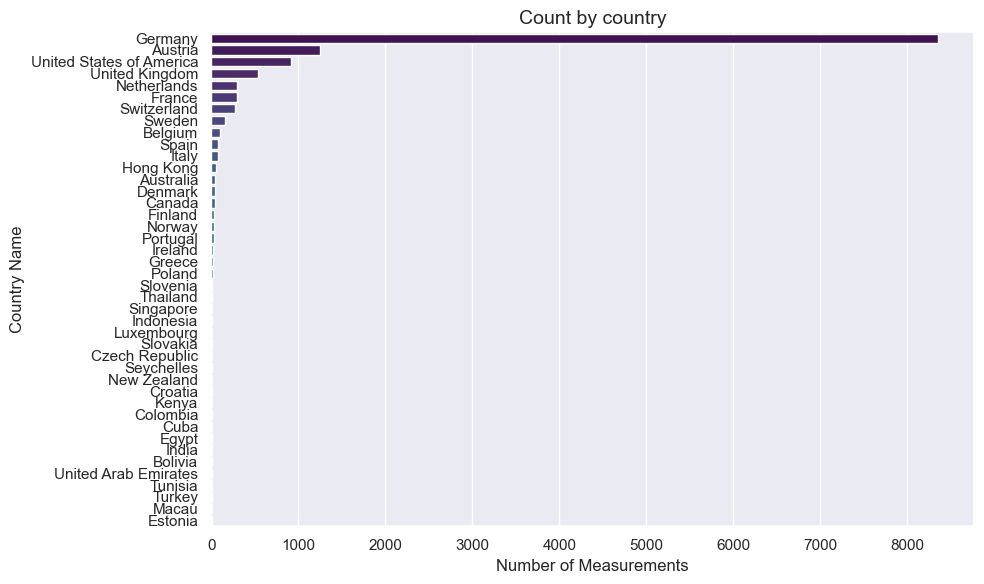

In [17]:
# Count occurrences of each country
country_counts = indoorco2map["countryName"].value_counts().reset_index()
country_counts.columns = ["countryName", "count"]
print(country_counts)

sns.set_theme(style="darkgrid")

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=country_counts,
    x="count", 
    y="countryName", 
    palette="viridis"
)

plt.title("Count by country", fontsize=14)
plt.xlabel("Number of Measurements")
plt.ylabel("Country Name")


plt.tight_layout()
plt.show()

In [18]:
# Map of countries with folium
m = folium.Map(location=[20, 0], zoom_start=2)

# Add circle markers for each country
for _, row in indoorco2map.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=2,
        color="blue",
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['countryName']}"
    ).add_to(m)

# show the map in the nex markdown cell
m.save("mapa_co2_count.html")


Record map with folium: 
To learn how to use powerful graphics tools, we sought to create a bar chart of countries with participation, but this time on a world map, using longitude and latitude to plot each point where there were records. It is very similar to the original map presented by the creators of indoorco2map. Still, this time, I did it for academic purposes and to improve the visualization of the participating countries (complementing the bar chart).

<iframe src="https://yeikeer.github.io/IndoorCO2Map-Analysis/mapa_co2_count.html" width="100%" height="600"></iframe>


A filter was applied to the countries, selecting only those with more than 10 records, which were then sorted by average CO2 emissions (ascending). Using this filter, a circular angle bar chart was created to visualize the countries with the highest comparative levels of $CO_2$ pollution inside commercial premises.

In [19]:
# Filter countries with more than 10 records
top_countries = country_counts[country_counts["count"] > 10]["countryName"]
filtered_df = indoorco2map[indoorco2map["countryName"].isin(top_countries)].copy()

# Average of averages CO2 by country
co2_avg_country = (
    filtered_df.groupby("countryName")["co2readingsAvg"]
    .mean()
    .reset_index()
    .rename(columns={"countryName": "Country", "co2readingsAvg": "Avg_CO2"})
)
co2_avg_country = co2_avg_country.sort_values(by="Avg_CO2", ascending=True)
print(co2_avg_country)


                     Country      Avg_CO2
13                    Norway   596.625000
17                     Spain   628.126582
5                    Finland   637.250000
18                    Sweden   661.069620
10                   Ireland   754.684211
15                  Portugal   756.041667
3                     Canada   768.476190
4                    Denmark   772.659091
20            United Kingdom   793.776316
0                  Australia   796.891304
9                  Hong Kong   799.568627
12               Netherlands   805.384354
19               Switzerland   817.096654
11                     Italy   829.085714
6                     France   842.793103
21  United States of America   868.781182
1                    Austria   878.191472
7                    Germany   880.566004
16                  Slovenia   886.363636
2                    Belgium   912.555556
8                     Greece   993.529412
14                    Poland  1203.933333


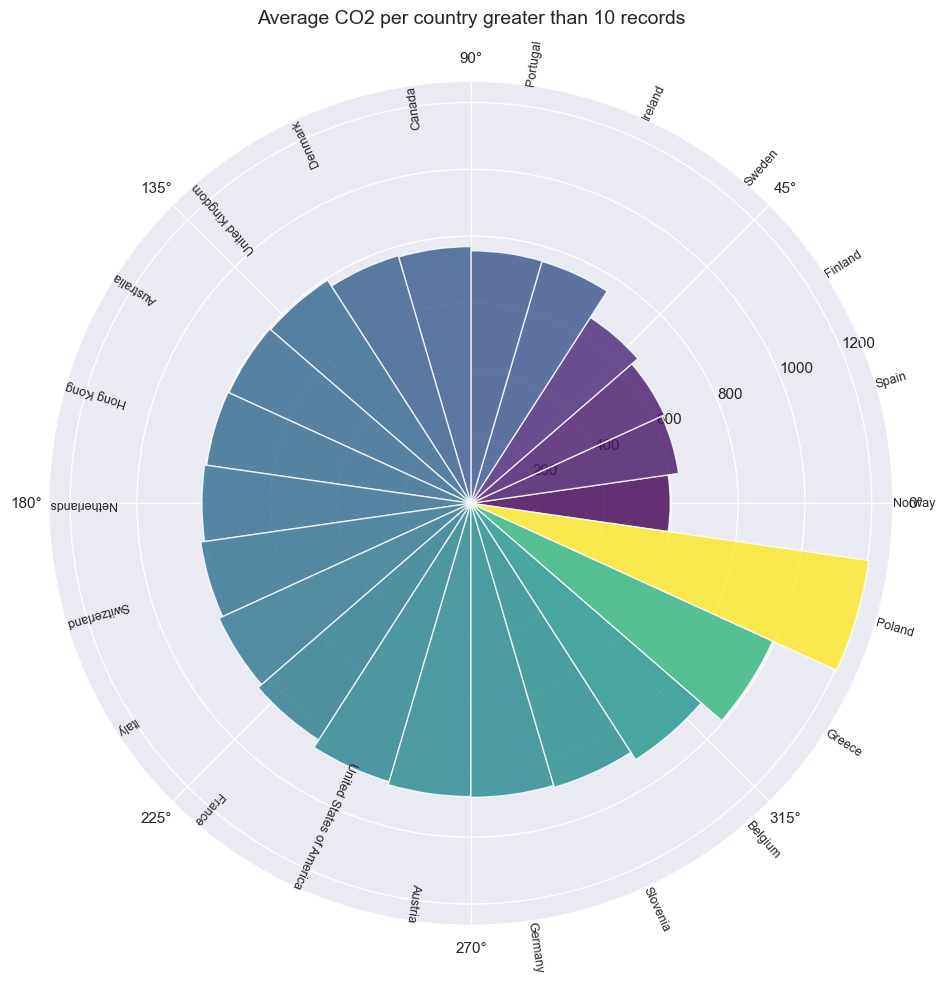

In [20]:
N = len(co2_avg_country)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False)

values = co2_avg_country["Avg_CO2"].values
countries = co2_avg_country["Country"].values


plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

bars = ax.bar(
    angles,
    values,
    width=2 * np.pi / N,
    bottom=0,
    color=plt.cm.viridis((values - min(values)) / (max(values) - min(values))),
    alpha=0.8
)

# Country labels
for angle, label in zip(angles, countries):
    rotation = np.degrees(angle)
    alignment = "right" if np.pi/2 < angle < 3*np.pi/2 else "left"
    ax.text(angle, max(values)*1.05, label, size=9, rotation=rotation, 
            rotation_mode="anchor", ha=alignment, va="center")

plt.title("Average CO2 per country greater than 10 records", size=14, pad=20)


plt.tight_layout()
plt.show()

Another complementary graph was created to visualize the countries with the highest pollution levels, in the form of a world map, allowing us to graphically identify whether location affected $CO_2$ levels. One of the patterns I identified was that the coldest countries in Europe tend to have low $CO_2$ levels (Norway, Sweden, Finland), and it can be highlighted that Poland presents an inequality compared to the other countries, having the highest level of $CO_2$ indoors.

Note: Some colonies or countries that are enclaves of others are marked with the same $CO_2$ level as their ally (e.g. French Guiana).

In [21]:
# Dowload GeoJSON data for world countries
url = "https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json"
world_geo = requests.get(url).json()

m2 = folium.Map(location=[20, 0], zoom_start=2)

# colors 
folium.Choropleth(
    geo_data=world_geo,
    data=co2_avg_country,
    columns=["Country", "Avg_CO2"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",       
    fill_opacity=0.7,
    line_opacity=0.2,
    nan_fill_color="lightgrey",
    legend_name=""
).add_to(m2)

# show the map in the nex markdown cell
m2.save("mapa_co2_prom.html")



<iframe src="https://yeikeer.github.io/IndoorCO2Map-Analysis/mapa_co2_prom.html" width="100%" height="600"></iframe>

Using the categories from the original dataframe, which establish whether mechanical ventilation and natural ventilation are active or not (“ventilationSystem” and ‘windowsOpen’), two new classes were created from conditionals, distributing the data as follows: Ventilation type: “none,” “mechanical,” “both,” or “natural.”

In [22]:
def classify_ventilation(row):
    mech = str(row["ventilationSystem"]).strip().lower() == "true"
    nat = str(row["windowsOpen"]).strip().lower() == "true"
    
    if mech and nat:
        return "both"
    elif mech:
        return "mechanical"
    elif nat:
        return "natural"
    else:
        return "none"

indoorco2map["ventilation_type"] = indoorco2map.apply(classify_ventilation, axis=1)

ventilation_medians = (
    indoorco2map.groupby("ventilation_type")["co2readingsMed"]
    .median()
    .reset_index()
    .rename(columns={"co2readingsMed": "Median_CO2"})
    .sort_values("Median_CO2", ascending=False)
)

C:\Users\mlondono\AppData\Local\Temp\ipykernel_8032\968052341.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


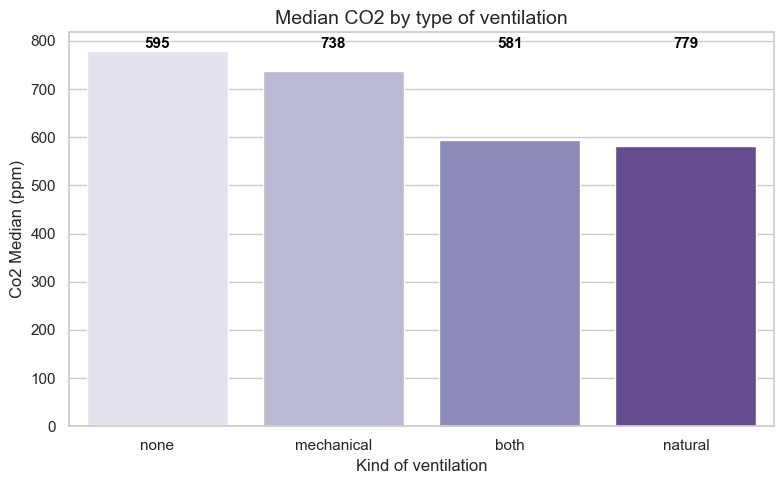

In [23]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

#Colors palette
palette = sns.color_palette("Purples", n_colors=len(ventilation_medians))

ax = sns.barplot(
    data=ventilation_medians,
    x="ventilation_type",
    y="Median_CO2",
    palette=palette
)

plt.title("Median CO2 by type of ventilation", fontsize=14)
plt.xlabel("Kind of ventilation")
plt.ylabel("Co2 Median (ppm)")

# Align and place text labels above bars
y_text = ventilation_medians["Median_CO2"].max() * 1.0

for i, row in ventilation_medians.iterrows():
    ax.text(i, y_text, f"{row['Median_CO2']:.0f}", 
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

C:\Users\mlondono\AppData\Local\Temp\ipykernel_8032\1831711374.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


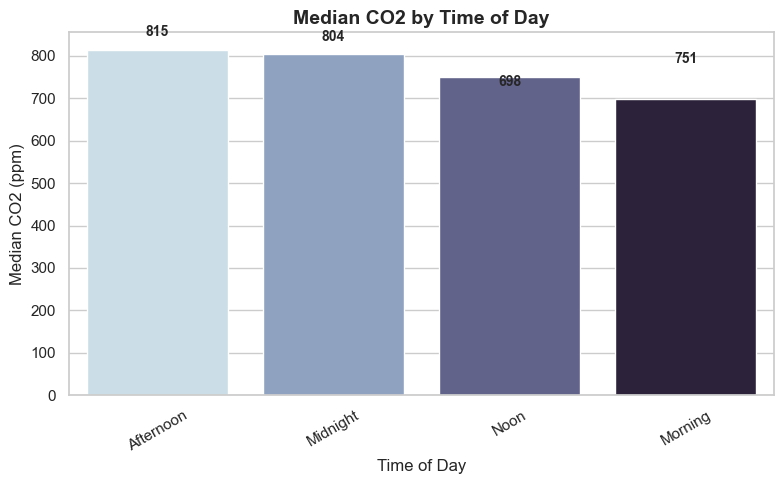

In [24]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))


time_medians = (
    indoorco2map.groupby("timeOfDay")["co2readingsMed"]
    .median()
    .reset_index(name="Median_CO2")
    .sort_values("Median_CO2", ascending=False)
)


palette = sns.color_palette("ch:s=.25,rot=-.25", n_colors=len(time_medians))

ax = sns.barplot(
    data=time_medians,
    x="timeOfDay",
    y="Median_CO2",
    palette=palette
)

plt.title("Median CO2 by Time of Day", fontsize=14, fontweight="bold")
plt.xlabel("Time of Day")
plt.ylabel("Median CO2 (ppm)")
plt.xticks(rotation=30)


for i, row in time_medians.iterrows():
    ax.text(
        i, row["Median_CO2"] + (time_medians["Median_CO2"].max() * 0.03),
        f"{row['Median_CO2']:.0f}",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

C:\Users\mlondono\AppData\Local\Temp\ipykernel_8032\1835968491.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\mlondono\AppData\Local\Temp\ipykernel_8032\1835968491.py:6: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


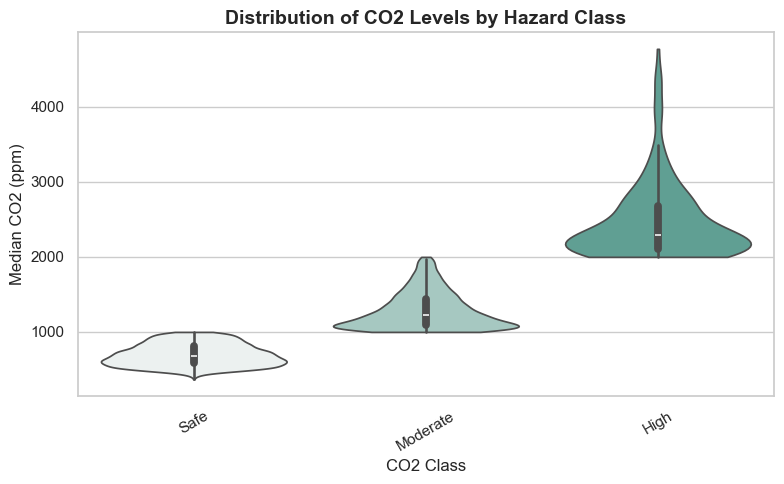

In [25]:
indoorco2map = indoorco2map[indoorco2map["co2_class"] != "Risky"] # drop "Risky" class due to low representation

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=indoorco2map,
    x="co2_class",
    y="co2readingsMed",
    palette="light:#5A9",
    inner="box",
    scale="width",
    cut=0
)

plt.title("Distribution of CO2 Levels by Hazard Class", fontsize=14, fontweight="bold")
plt.xlabel("CO2 Class")
plt.ylabel("Median CO2 (ppm)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The graphs created for the invented classifications of ventilation type, time of day, and CO2 hazard category show that: 1. Mechanical ventilation increases indoor CO2 levels, 2. The highest CO2 concentrations occur at night (afternoon and midnight), and 3. None of the three classes (Safe, Moderate, High) has a visually normal distribution.

# 5. Data separability 

A copy of the indoorco2map dataframe is created with only the columns of interest to observe class separability, first with a pairplot graph and then with hypothesis testing.

In [26]:
inspector = DataPrint(indoorco2map)
cols = ["ventilation_type", "timeOfDay", "co2_class"]
inspector(cols)


ventilation_type
none          10984
mechanical      936
natural         608
both            152
Name: count, dtype: int64
Size: 12680


timeOfDay
Noon         7070
Afternoon    3693
Morning      1348
Midnight      569
Name: count, dtype: int64
Size: 12680


co2_class
Safe        9411
Moderate    3049
High         220
Name: count, dtype: int64
Size: 12680



## Selection of classifier

### Hazard classifier: co2_class
A comprehensive graphical study was conducted to identify which classifier to use as the main one. Ultimately, for academic purposes, it was decided to use co2_class, even though this classifier was created based on the median of $CO_2$ measurements and its separability is clearly biased by the conditions applied. It serves as an example of the application of variability measurement through graphs and hypothesis testing. The other cases did not represent any visual relationship or separation.

## Selection of characteristics 

### Numerical characteristics
The time-dependent and time-independent statistical descriptors calculated above will now be analyzed to select the best ones to serve as characteristics defining class separability. The following table explains each statistic:

| **Column** | **Operation applied** | **Interpretation / Usefulness** |
|-------------|-----------------------|----------------------------------|
| `co2readingsAvg` | Arithmetic mean of the $CO_2$ readings (**np.mean**) | Represents the average $CO_2$ level during the measurement period. Provides a general indication of air quality. |
| `co2readingsMed` | Median of the $CO_2$ readings (**np.median**) | A robust central value less sensitive to outliers. Indicates the “typical” $CO_2$ level during the sampling. |
| `co2readingsStd` | Standard deviation (**np.std**) | Measures how much the readings vary around the mean. High values indicate strong fluctuations in $CO_2$ concentration. |
| `co2readingsVar` | Variance (**np.var**) | Square of the standard deviation. Represents the overall magnitude of variability in the readings. |
| `co2readingsMin` | Minimum value (**np.min**) | The lowest $CO_2$ concentration recorded in the session. Useful for identifying periods of good ventilation. |
| `co2readingsMax` | Maximum value (**np.max**) | The highest $CO_2$ concentration recorded. Indicates possible accumulation events or peaks. |
| `co2readingsRange` | Difference between max and min (**np.max - np.min**) | Describes the range of variation in $CO_2$ levels during measurement. A wide range means strong temporal variability. |
| `co2readingsRMS` | Root Mean Square (**$\sqrt{meanX^{2}}$**) | Measures the average “energy level” of the $CO_2$ signal. Sensitive to high values, useful for comparing total magnitude. |
| `co2readingsCV` | Coefficient of Variation (**Std / Med**) | Relates variability to the median level. Allows comparing the relative stability of locations with different $CO_2$ magnitudes. |
| `co2readingsSlope` | Slope from a linear regression of $CO_2$ vs. time (**np.polyfit(..., 1))** | Indicates the temporal trend: positive = $CO_2$ buildup, negative = effective ventilation or decreasing concentration. |
| `co2readingsCurvature` | Quadratic coefficient from a 2nd-degree polynomial fit (**np.polyfit(..., 2)[0]**) | Measures the acceleration of the $CO_2$ trend. Positive = accelerating buildup; negative = deceleration. |
| `co2readingsMean_diff` | Mean absolute difference between consecutive readings (**mean($\Delta X $)**)| Quantifies the average magnitude of change between consecutive readings. Reflects temporal smoothness or fluctuation. |
| `co2readingsStd_diff` | Standard deviation of differences between consecutive readings (**std($\Delta X$)**) | Measures variability of the incremental changes. High values reflect oscillations or instability in air composition. |


There are three types of statistical characteristics among mine: those that measure absolute values or levels, those that measure variability, and those that measure temporal dynamics, which evaluate changes over time: 

| Type of statistic   | Examples                                      | They measure                                                                    |
| --------------------- | --------------------------------------------- | --------------------------------------------------------------------------- |
| **Absolute level**    | `Avg`, `Med`, `RMS`, `Max`, `Min`             | How high is the $CO_2$ level?.                                            |
| **Variability**      | `Std`, `Var`, `Range`, `CV`                   | How much do the measurements fluctuate?.                                          |
| **Temporal dynamics** | `Slope`, `Curvature`, `Mean_diff`, `Std_diff` | How $CO_2$ evolves over time (trend, acceleration, oscillations). |




C:\Users\mlondono\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


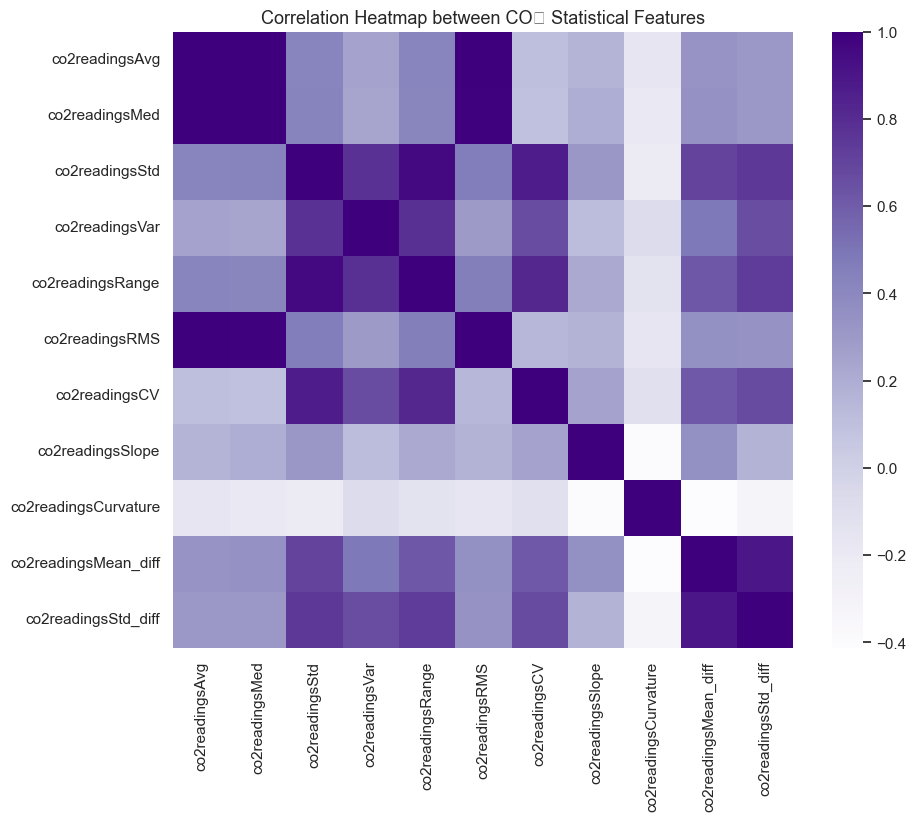

In [ ]:
corr = indoorco2map[
    ["co2readingsAvg", "co2readingsMed", "co2readingsStd", "co2readingsVar", 
     "co2readingsRange", "co2readingsRMS", "co2readingsCV", 
     "co2readingsSlope", "co2readingsCurvature", 
     "co2readingsMean_diff", "co2readingsStd_diff"]
].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="Purples", annot=False)
plt.title("Correlation Heatmap between CO2 Statistical Features", fontsize=13)
plt.show()

Many of these statistics are highly correlated because they are analytically similar or dependent on another formula. Therefore, with the help of a correlation matrix and statistical knowledge of the definition of each parameter, the most relevant ones were selected to conduct a separability study of the CO2_class classes.

In [70]:
cols = [
    "co2_class",               # Classifier
    "co2readingsMed",          # CO2 median
    "co2readingsStd",          # Standard deviation
    "co2readingsCV",           # Coefficient of Variation
    "co2readingsSlope",        # Slope
    "co2readingsCurvature",    # Curvature
    "co2readingsStd_diff",     # Variability of changes
]
df = indoorco2map[cols].copy()

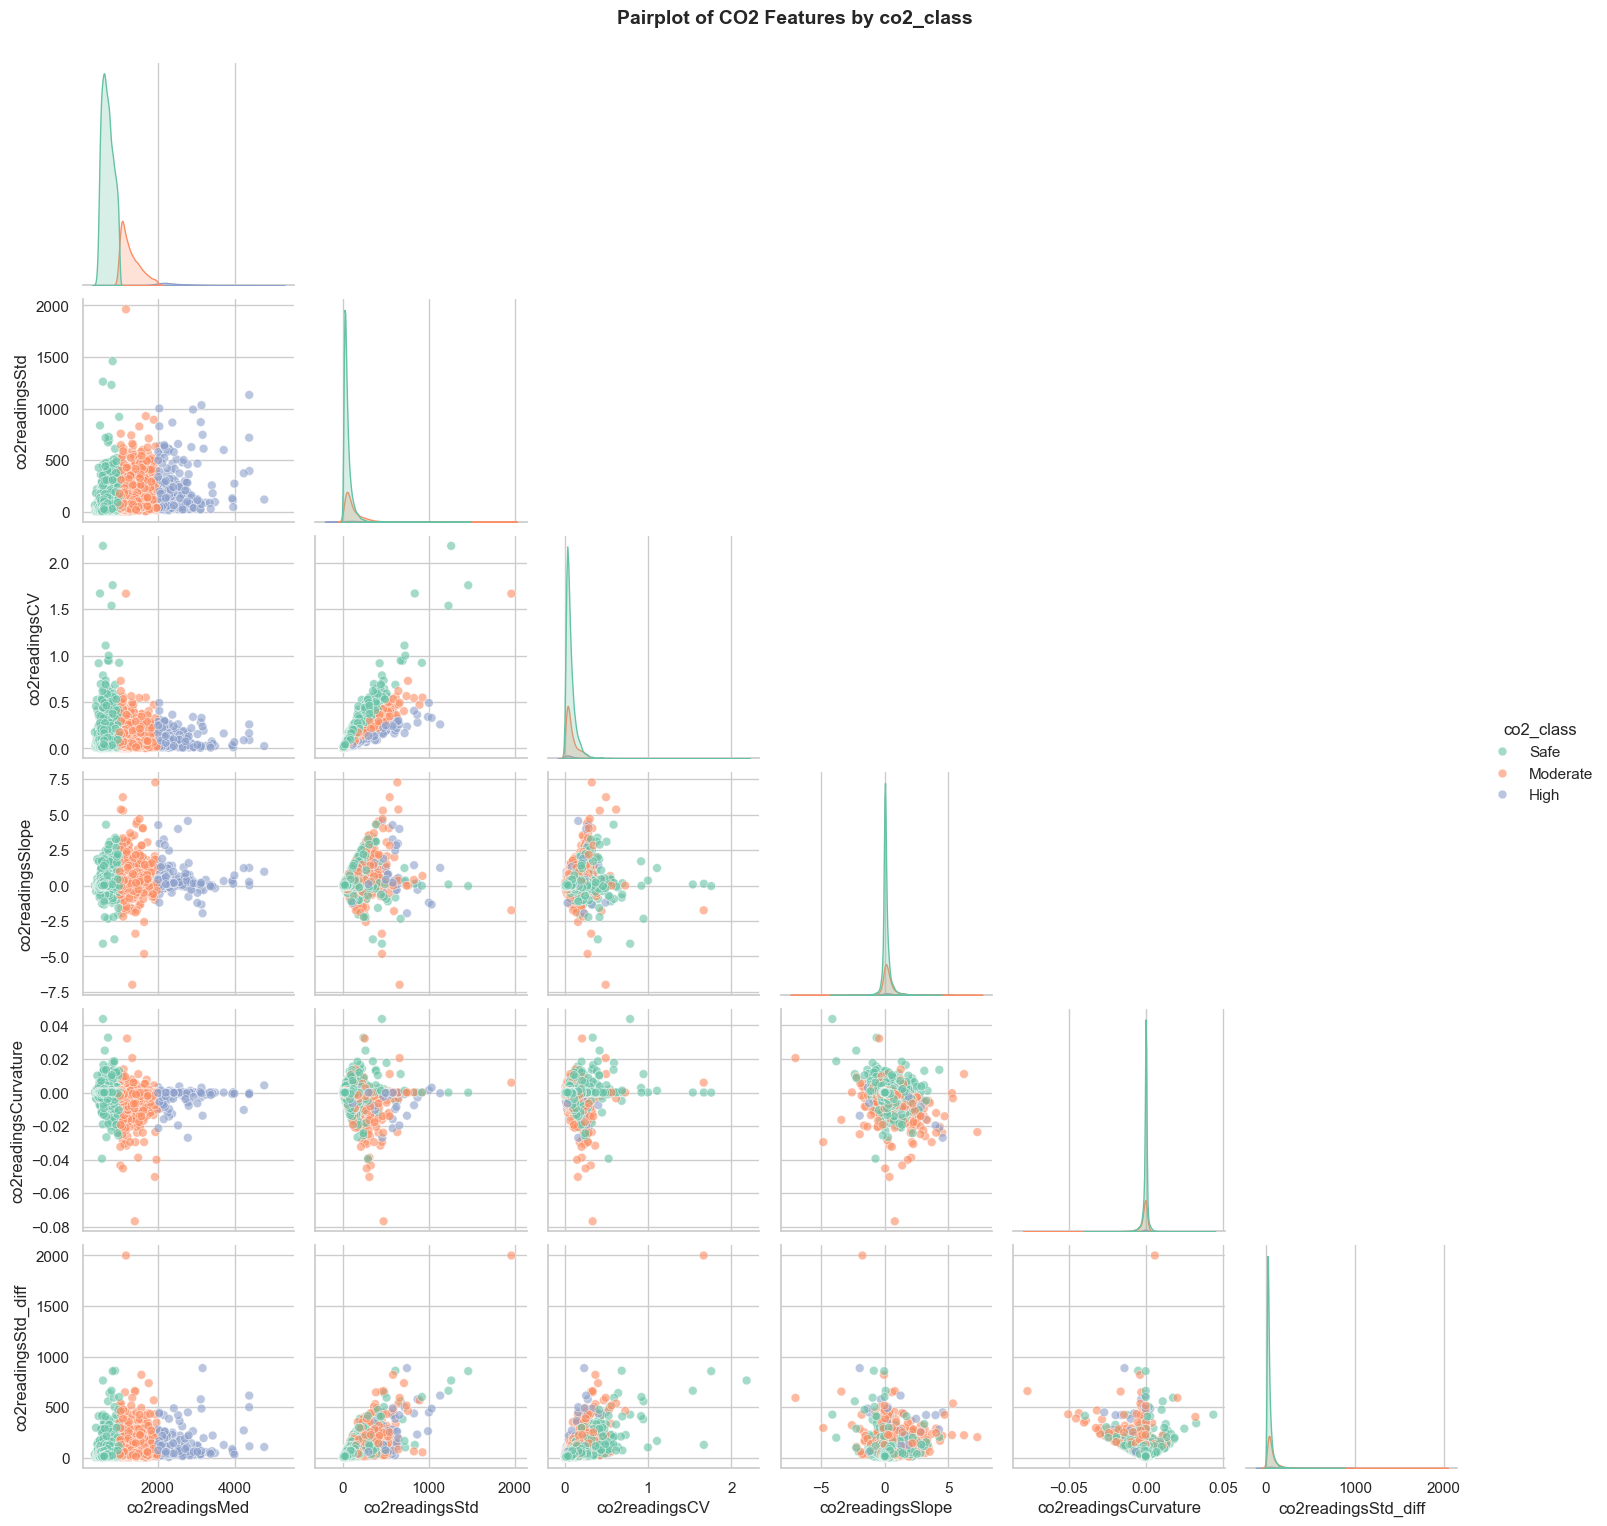

In [74]:
sns.set_theme(style="whitegrid", context="notebook")

pair = sns.pairplot(
    df,
    hue="co2_class",
    palette="Set2",
    diag_kind="kde",
    plot_kws={"alpha": 0.6, "s": 40},
    corner=True
)

pair.fig.suptitle("Pairplot of CO2 Features by co2_class", y=1.02, fontsize=14, fontweight="bold")
plt.show()

### Categorical characteristics 

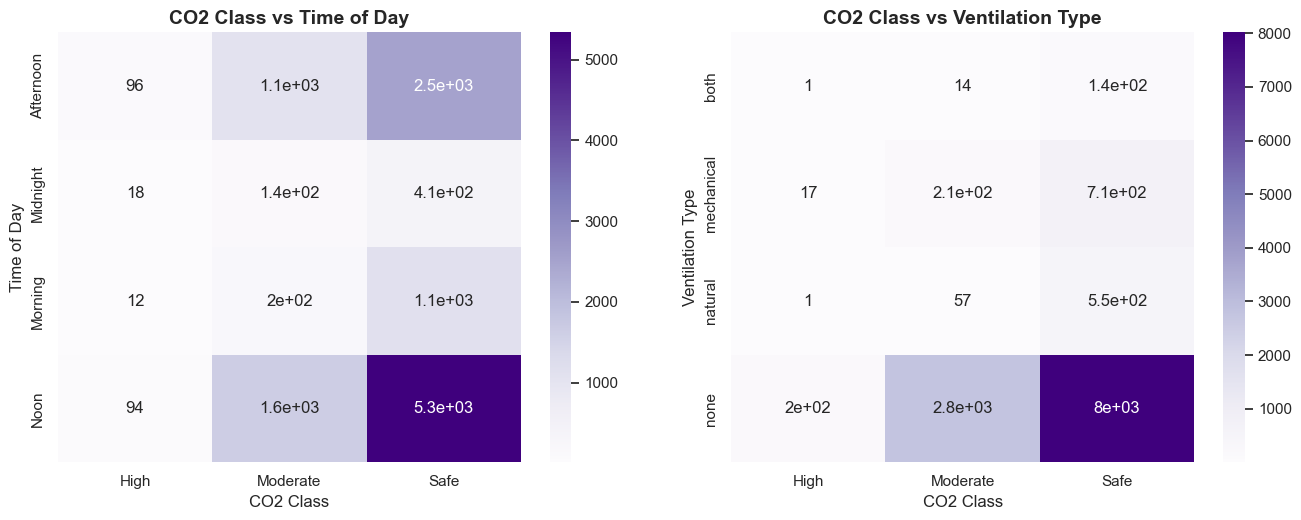

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cros = pd.crosstab(indoorco2map["timeOfDay"], indoorco2map["co2_class"])
cros2 = pd.crosstab(indoorco2map["ventilation_type"], indoorco2map["co2_class"])

sns.heatmap(data=cros, annot=True, cmap="Purples", ax=axes[0])
axes[0].set_title("CO2 Class vs Time of Day", fontsize=14, fontweight="bold")
axes[0].set_xlabel("CO2 Class", fontsize=12)
axes[0].set_ylabel("Time of Day", fontsize=12)


sns.heatmap(data=cros2, annot=True, cmap="Purples", ax=axes[1])
axes[1].set_title("CO2 Class vs Ventilation Type", fontsize=14, fontweight="bold")
axes[1].set_xlabel("CO2 Class", fontsize=12)
axes[1].set_ylabel("Ventilation Type", fontsize=12)


plt.tight_layout(pad=3.0)
plt.show()

We use correlation matrices to select numerical variables, and heat maps, histograms, and geographic maps to select categorical variables, as shown in the following code:

In [76]:
# Numeric variables of interest
numeric_features = [
    "co2readingsMed",
    "co2readingsStd",
    "co2readingsCV",
    "co2readingsSlope",
    "co2readingsCurvature",
    "co2readingsStd_diff"
]

# Categorical variables of interest
categorical_features = [
    "timeOfDay",
    "ventilation_type",
    "countryName",
    "osmKey",
    "co2_class"   # Classifier
]

# New DataFrame with selected features
df_mixed = indoorco2map[numeric_features + categorical_features].copy()

print(df_mixed.head())

   co2readingsMed  co2readingsStd  co2readingsCV  co2readingsSlope  \
0           560.0       25.972742       0.046380          0.160476   
1           661.0       14.302447       0.021638         -0.115000   
2           931.0       47.622649       0.051152          0.108095   
3          1648.0      174.543930       0.105913          1.157619   
4           746.0       75.499966       0.101206          0.490476   

   co2readingsCurvature  co2readingsStd_diff  timeOfDay ventilation_type  \
0              0.001176            31.442646  Afternoon       mechanical   
1              0.000972            18.833149       Noon       mechanical   
2             -0.002113            77.502516       Noon             both   
3             -0.013601           158.226420  Afternoon       mechanical   
4             -0.003201            61.268988  Afternoon       mechanical   

  countryName osmKey co2_class  
0     Germany   shop      Safe  
1     Germany   shop      Safe  
2     Germany   shop   

## Hypothesis testing (Numericals)

### Normalcy numerical characteristics 

The Kolmogorov test will be used to test the normality of the numerical characteristics, since we have more than 12,000 samples, and the Shapiro-Wilk is recommended for low quantities (<5,000).

Kolmogorov assumes standard normal distributions with mean=0 and sdt=1, so we will normalize each variable with the z-score.

In [ ]:

df_num = df_mixed[numeric_features].copy()
df_num = df_num.apply(zscore)

ks_results = {}

for col in df_num.columns:
    
    col_clean = df_num[col][np.isfinite(df_num[col])].dropna()
    
   
    if len(col_clean) > 10 and col_clean.nunique() > 1:
        try:
            stat, p_value = kstest(col_clean, 'norm')
        except Exception:
            stat, p_value = np.nan, np.nan
    else:
        stat, p_value = np.nan, np.nan

    ks_results[col] = {"KS_statistic": stat, "p_value": p_value}

ks_df = pd.DataFrame(ks_results).T
ks_df["Normality(α=0.05)"] = ks_df["p_value"].apply(lambda x: "Normal" if pd.notna(x) and x > 0.05 else "Not Normal")

pd.options.display.float_format = '{:.2e}'.format
print("Kolmogorov–Smirnov Normality Test Results:\n")
print(ks_df)

Kolmogorov–Smirnov Normality Test Results:

                      KS_statistic   p_value Normality(α=0.05)
co2readingsMed            1.29e-01 9.65e-185        Not Normal
co2readingsStd            2.23e-01  0.00e+00        Not Normal
co2readingsCV             1.93e-01  0.00e+00        Not Normal
co2readingsSlope               NaN       NaN        Not Normal
co2readingsCurvature           NaN       NaN        Not Normal
co2readingsStd_diff       2.39e-01  0.00e+00        Not Normal


Although some characteristics showed abnormality, the curvature and slope characteristics did not yield results. This is because they do not present great variability in the internal data (less than 0) or the quantity is very small (some values are null). The Kolmogorov–Smirnov test fails because:

+ It cannot calculate an empirical distribution (zero variance).
+ The sample size is insufficient to estimate the shape of the distribution.

In [91]:
print(indoorco2map["co2readingsSlope"].describe())
print(indoorco2map["co2readingsCurvature"].describe())


count    9.99e+03
mean     1.53e-01
std      4.52e-01
min     -7.00e+00
25%     -1.29e-02
50%      5.74e-02
75%      2.31e-01
max      7.27e+00
Name: co2readingsSlope, dtype: float64
count    9.99e+03
mean    -7.21e-04
std      3.14e-03
min     -7.67e-02
25%     -8.33e-04
50%     -7.65e-05
75%      5.42e-05
max      4.38e-02
Name: co2readingsCurvature, dtype: float64


### Kruskal-Wallis test

Since we have more than three characteristics, with more than 10,000 samples and with the quality of being non-parametric (non-normality), the Kruskal-Wallis hypothesis test will be applied to determine whether there are significant differences between classes.

In [93]:

df_test = df_mixed[numeric_features + ["co2_class"]].copy()


kruskal_results = {}


for col in numeric_features:
   
    grouped_data = [
        df_test[df_test["co2_class"] == cls][col].dropna() 
        for cls in df_test["co2_class"].unique() if df_test[df_test["co2_class"] == cls][col].notna().sum() > 0
    ]
    
    
    if len(grouped_data) > 1:
        try:
            stat, p_value = kruskal(*grouped_data)
        except Exception:
            stat, p_value = np.nan, np.nan
    else:
        stat, p_value = np.nan, np.nan
    
    kruskal_results[col] = {"H_statistic": stat, "p_value": p_value}


kruskal_df = pd.DataFrame(kruskal_results).T
kruskal_df["Significant(alpha=0.05)"] = kruskal_df["p_value"].apply(lambda x: "Yes" if pd.notna(x) and x < 0.05 else "No")

pd.options.display.float_format = '{:.2e}'.format
print("Kruskal–Wallis Test Results (CO2 class as grouping variable):\n")
print(kruskal_df)

Kruskal–Wallis Test Results (CO2 class as grouping variable):

                      H_statistic   p_value Significant(alpha=0.05)
co2readingsMed           7.32e+03  0.00e+00                     Yes
co2readingsStd           1.78e+03  0.00e+00                     Yes
co2readingsCV            7.86e+01  8.63e-18                     Yes
co2readingsSlope         4.44e+02  4.05e-97                     Yes
co2readingsCurvature     4.90e+02 3.75e-107                     Yes
co2readingsStd_diff      1.57e+03  0.00e+00                     Yes


C:\Users\mlondono\AppData\Local\Temp\ipykernel_8032\2311508624.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mlondono\AppData\Local\Temp\ipykernel_8032\2311508624.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mlondono\AppData\Local\Temp\ipykernel_8032\2311508624.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mlondono\AppData\Local\Temp\ipykernel_8032\2311508624.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

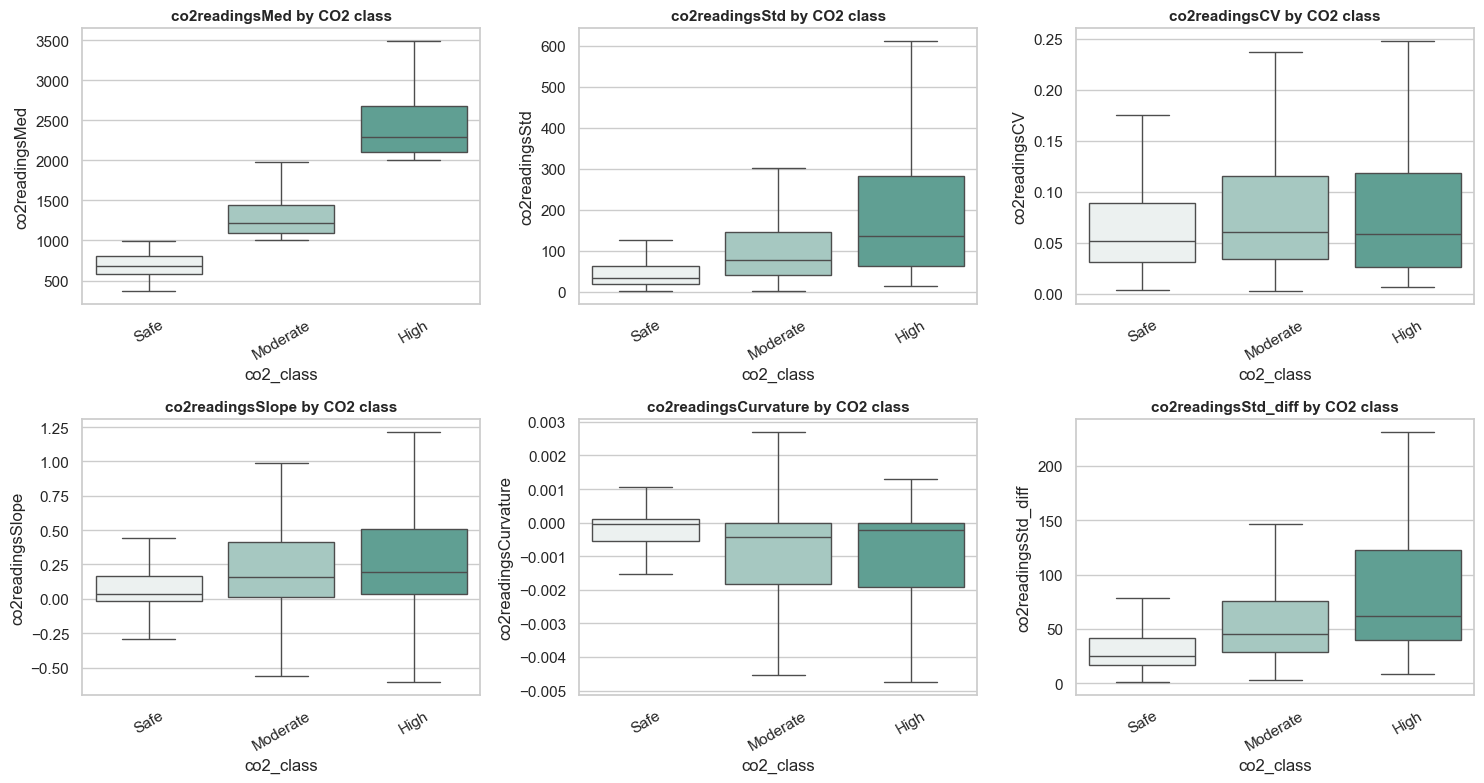

In [113]:
significant_features = kruskal_df[kruskal_df["Significant(alpha=0.05)"] == "Yes"].index

plt.figure(figsize=(15, 8))
for i, feature in enumerate(significant_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(
        data=indoorco2map,
        x="co2_class",
        y=feature,
        palette="light:#5A9",
        showfliers=False
    )
    plt.title(f"{feature} by CO2 class", fontsize=11, fontweight="bold")
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The hypothesis test gives us all p-values lower than 0.05, therefore explaining that there is a significant difference in all characteristics with respect to the class; However, there are discrepancies with respect to the graphical method, since visually the characteristics co2readingsCV, co2readingsSlope, and co2readingsCurvature do not show this difference compared to the rest (Box Plot). 

## Chi-square of independence (Categoricals)

Allows us to assess whether there is a statistically significant association between categorical variables (e.g., $CO_2$ classes and factors such as country, type of ventilation, or time of day). In this case, it serves to determine whether the distribution of $CO_2$ classes depends on the value of the category analyzed, i.e., whether these variables contribute to differentiating $CO_2$ concentration levels.

In [106]:
categorical_features = [
    "timeOfDay",
    "ventilation_type",
    "countryName",
    "osmKey"
]

chi2_results = {}

for col in categorical_features:

    contingency = pd.crosstab(df_mixed[col], df_mixed["co2_class"])
    

    if contingency.shape[0] > 1 and contingency.shape[1] > 1:
        try:
            chi2, p, dof, expected = chi2_contingency(contingency)
        except Exception:
            chi2, p = np.nan, np.nan
    else:
        chi2, p = np.nan, np.nan

    chi2_results[col] = {
        "Chi2_statistic": chi2,
        "p_value": p
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df["Significant(alpha=0.05)"] = chi2_df["p_value"].apply(lambda x: "Yes" if pd.notna(x) and x < 0.05 else "No")

pd.options.display.float_format = '{:.2e}'.format
print("Chi-square Test of Independence (vs. CO2 class):\n")
print(chi2_df)

Chi-square Test of Independence (vs. CO2 class):

                  Chi2_statistic  p_value Significant(alpha=0.05)
timeOfDay               1.58e+02 1.46e-31                     Yes
ventilation_type        1.14e+02 2.64e-22                     Yes
countryName             2.03e+02 2.98e-12                     Yes
osmKey                  1.39e+02 3.56e-18                     Yes


C:\Users\mlondono\AppData\Local\Temp\ipykernel_8032\2255524418.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.02599513 0.03163445 0.00890208 0.01329562]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  bottom_vals[subset[col]] += subset["Proportion"].values
C:\Users\mlondono\AppData\Local\Temp\ipykernel_8032\2255524418.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.00657895 0.01816239 0.00164474 0.01829934]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  bottom_vals[subset[col]] += subset["Proportion"].values
C:\Users\mlondono\AppData\Local\Temp\ipykernel_8032\2255524418.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.         0.01287

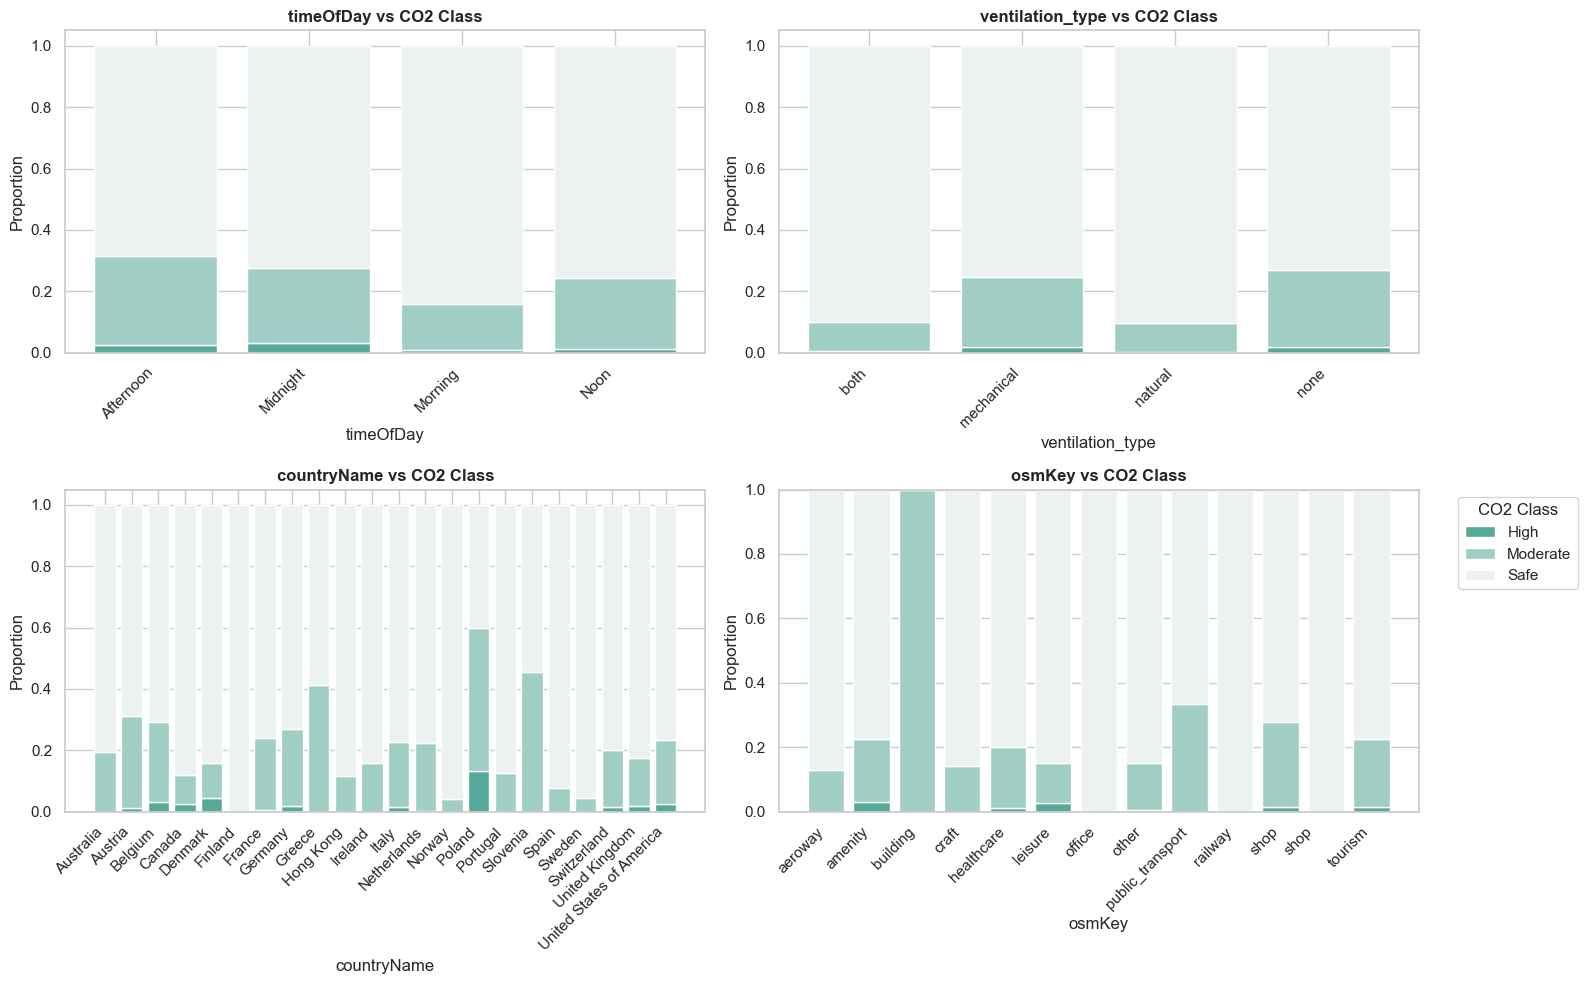

In [117]:
plt.figure(figsize=(16, 10))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)

    if col == "countryName":
        counts = df_mixed["countryName"].value_counts()
        valid_countries = counts[counts > 10].index
        df_plot = df_mixed[df_mixed["countryName"].isin(valid_countries)]
    else:
        df_plot = df_mixed.copy()

    crosstab = pd.crosstab(df_plot[col], df_plot["co2_class"], normalize="index")

    df_melted = crosstab.reset_index().melt(id_vars=col, var_name="CO2 Class", value_name="Proportion")

    bottom_vals = pd.Series([0]*len(df_melted[col].unique()), index=df_melted[col].unique())
    colors = sns.color_palette("light:#5A9_r", n_colors=len(df_melted["CO2 Class"].unique()))

    for j, co2_class in enumerate(df_melted["CO2 Class"].unique()):
        subset = df_melted[df_melted["CO2 Class"] == co2_class]
        plt.bar(
            subset[col],
            subset["Proportion"],
            bottom=bottom_vals[subset[col]].values,
            label=co2_class,
            color=colors[j]
        )
        bottom_vals[subset[col]] += subset["Proportion"].values

    plt.title(f"{col} vs CO2 Class", fontsize=12, fontweight="bold")
    plt.ylabel("Proportion")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha="right")

plt.legend(title="CO2 Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

The chi-square hypothesis test used to evaluate categorical vs. categorical characteristics shows us that there is a significant difference in each characteristic with respect to our "co2_class" hazard class. If we also apply graphical analysis, we see that the most predominant class is “safe.” The characteristics “country” and “osmKey” are the ones that provide the most information to differentiate the classes; however, I consider that the characteristics ‘timeOfDay’ and “ventilation_type” are not negligible and can provide a differential, in addition to which I consider that the four categorical characteristics have a high relevance/importance due to the information they contain or allow us to analyze.

# Conclusions 

1) According to US health organizations, ranges in ppm of $CO_2$ are established where it represents a danger and how it affects:  

| **$CO_2$ (ppm)**                | **$CO_2$ (%)** | **Effects and Risks**                                                                                 |
| ----------------------------: | ----------: | ----------------------------------------------------------------------------------------------------- |
| **400 – 1,000**              | 0.04 – 0.1  | Typical level in outdoor air (400 ppm) and well-ventilated offices (up to 1,000 ppm). No adverse effects. |
| **1,000 – 2,000**            | 0.1 – 0.2   | May cause mild drowsiness and stuffy air. Indicates insufficient ventilation.                         |
| **2,000 – 5,000**            | 0.2 – 0.5   | Headaches, drowsiness, lack of concentration, and feeling of congestion.                              |
| **5,000**  | 0.5         | Occupational exposure limit for 8 hours/day (PEL, TLV). Prolonged exposure not recommended.            |
| **5,000 – 10,000**           | 0.5 – 1     | Significant increase in symptoms: fatigue, dizziness, mild confusion.                                 |
| **10,000 – 15,000**          | 1 – 1.5     | Nausea, increased heart rate, dizziness, reduced concentration.                                       |
| **15,000 – 30,000**          | 1.5 – 3     | Severe dizziness, strong headaches, risk of prolonged loss of consciousness.                          |
| **30,000 – 50,000**          | 3 – 5       | Acute hypercapnia: confusion, breathing difficulty, loss of consciousness within minutes.              |
| **>50,000**                  | >5          | Severe danger: asphyxiation, convulsions, respiratory arrest, and death within minutes.               |

**Reference:** OSHA (Occupational Safety and Health Administration)/NIOSH (National Institute for Occupational Safety and Health)  limit ppm of CO2 indoors

When applying this same filter to the indoorco2map data, we find that with the median of the measurements, only one record exceeded the 5000 ppm levels, with the other values falling within the limits permitted by OSHA/NIOSH (5000 ppm). Furthermore, the highest readings were below 1000 ppm, and very few premises had ppm levels that caused discomfort. This leads to the conclusion that commercial establishments have higher CO2 concentrations than the outside atmosphere, but comply with regulations in that none of them expose users to danger. For this reason, commercial establishments and residential buildings are not the focus of my research project.

_____________________________________________________________________________________________________________________

2) It was found that mechanical ventilation increases indoor CO2 levels, even more so than if no ventilation were used. This phenomenon does not fit with health studies that explain that ventilation (whether natural or not) helps to reduce CO2 in enclosed spaces. This could be due to the type of mechanical ventilation referred to, as some of these may be heating or ventilation with carbon sources or fossil fuels.
On the other hand, global graphs have shown that colder countries tend to have lower CO2 levels, which is also due to their lack of mechanical ventilation:


| Country | Count |
| :--- | :--- |
| **Norway** | 0 |
| **Finland** | 2 |
| **Sweden** | 5 |


A very relevant study that could be done in the future would be to establish the season of the year in which the measurement was taken using the calculated absolute date, as well as including databases of average temperature and humidity for each country or even consulting the most relevant ones for the type of mechanical ventilation that predominates (fossil fuel, or if it is only ventilation or heating).

_____________________________________________________________________________________________________________________

3) Finally, after an exhaustive study of characteristics, transformed and filtered, a list of the most relevant characteristics with greater separability for the $CO_2$ level class “co2_class” can be concluded:


| **Variable (Python name)** | **Description / Meaning**                                                                                       |
| -------------------------- | --------------------------------------------------------------------------------------------------------------- |
| `co2readingsMed`           | Median of CO₂ readings during the measurement period. Represents the typical concentration level.               |
| `co2readingsStd`           | Standard deviation of CO₂ readings. Indicates the variability or fluctuations in concentration.                 |
| `co2readingsStd_diff`      | Standard deviation of consecutive CO₂ differences. Reflects short-term instability or oscillation.              |
| `timeOfDay`                | Classification of the measurement period based on time (Midnight, Morning, Noon, Afternoon).                    |
| `ventilation_type`         | Type of ventilation present in the location (natural, mechanical, or both active).                              |
| `countryName`              | Country where the measurement was recorded (only those with >10 valid records were analyzed).                   |
| `osmKey`                   | Key describing the type of establishment (e.g., restaurant, shop, office) according to OpenStreetMap tagging.   |
| `co2_class`                | CO₂ exposure risk classification based on ppm ranges (Safe, Moderate, High, etc.). Used as the main classifier. |

If a predictive model or a new study were to be conducted, these variables would be included as the most relevant when training and collecting new data.